# 07 — Beta-hedged versus equal-dollar sizing

Compare the two sizing choices using the same top-11 pairs and rolling signal. All analysis and backtests in this notebook use **days 1–700 only**; performance is measured on validation days **501–700**.

## What is being tested?

- **Beta hedging:** shares follow the fitted hedge ratio, subject to each leg's $10k cap.
- **Equal dollar:** each leg targets roughly $10k; beta is used only for the spread signal.

A stable beta supports beta-hedged sizing. A noisy or drifting beta is a reason to prefer equal-dollar sizing.

In [4]:
from pathlib import Path
import importlib.util
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DISCOVERY_END = 500
VALIDATION_END = 700
ROLLING_WINDOW = 250

repo_root = next((path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'backtester').exists()), None)
if repo_root is None:
    raise FileNotFoundError('Run this notebook from inside the project directory.')
sys.path.insert(0, str(repo_root / 'backtester'))
from backtest.engine import run_backtest
from backtest.metrics import compute_metrics

price_path = repo_root / 'backtester' / 'data' / '2026' / 'prices.txt'
price_frame = pd.read_csv(price_path, sep=r'\s+', nrows=VALIDATION_END)
prices = price_frame.to_numpy(dtype=float).T
tickers = price_frame.columns.tolist()

def load_strategy(filename, module_name):
    spec = importlib.util.spec_from_file_location(module_name, repo_root / 'src' / 'strategies' / filename)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

beta_strategy = load_strategy('pairs_top_11_rolling_beta.py', 'beta_hedged')
equal_strategy = load_strategy('pairs_top_11_equal_dollar_rolling.py', 'equal_dollar')
assert beta_strategy.PAIRS == equal_strategy.PAIRS
print(f'{len(beta_strategy.PAIRS)} identical pairs; validation days {DISCOVERY_END + 1}–{VALIDATION_END}.')

11 identical pairs; validation days 501–700.


## 1. Hedge-beta stability

Each point is a 250-day rolling regression beta. Lower coefficient of variation (CV) means the hedge ratio is more stable.

,pair,mean_beta,beta_cv,beta_min,beta_max
1,NGTE-EORC,0.959,0.050,0.858,1.053
3,SMAH-ILVX,1.014,0.063,0.871,1.123
7,HUXZ-ACAC,0.920,0.077,0.737,1.047
6,NWIG-AENO,0.972,0.096,0.700,1.143
4,ULXY-HETT,0.925,0.135,0.663,1.178
9,ACIX-ITPA,1.068,0.159,0.811,1.411
0,EELT-CTGI,0.689,0.190,0.433,0.864
10,BLBT-FWWG,0.743,0.194,0.231,0.940
5,MHRM-EAFC,0.897,0.203,0.517,1.118
2,RTTH-NAYO,0.724,0.221,0.430,0.968


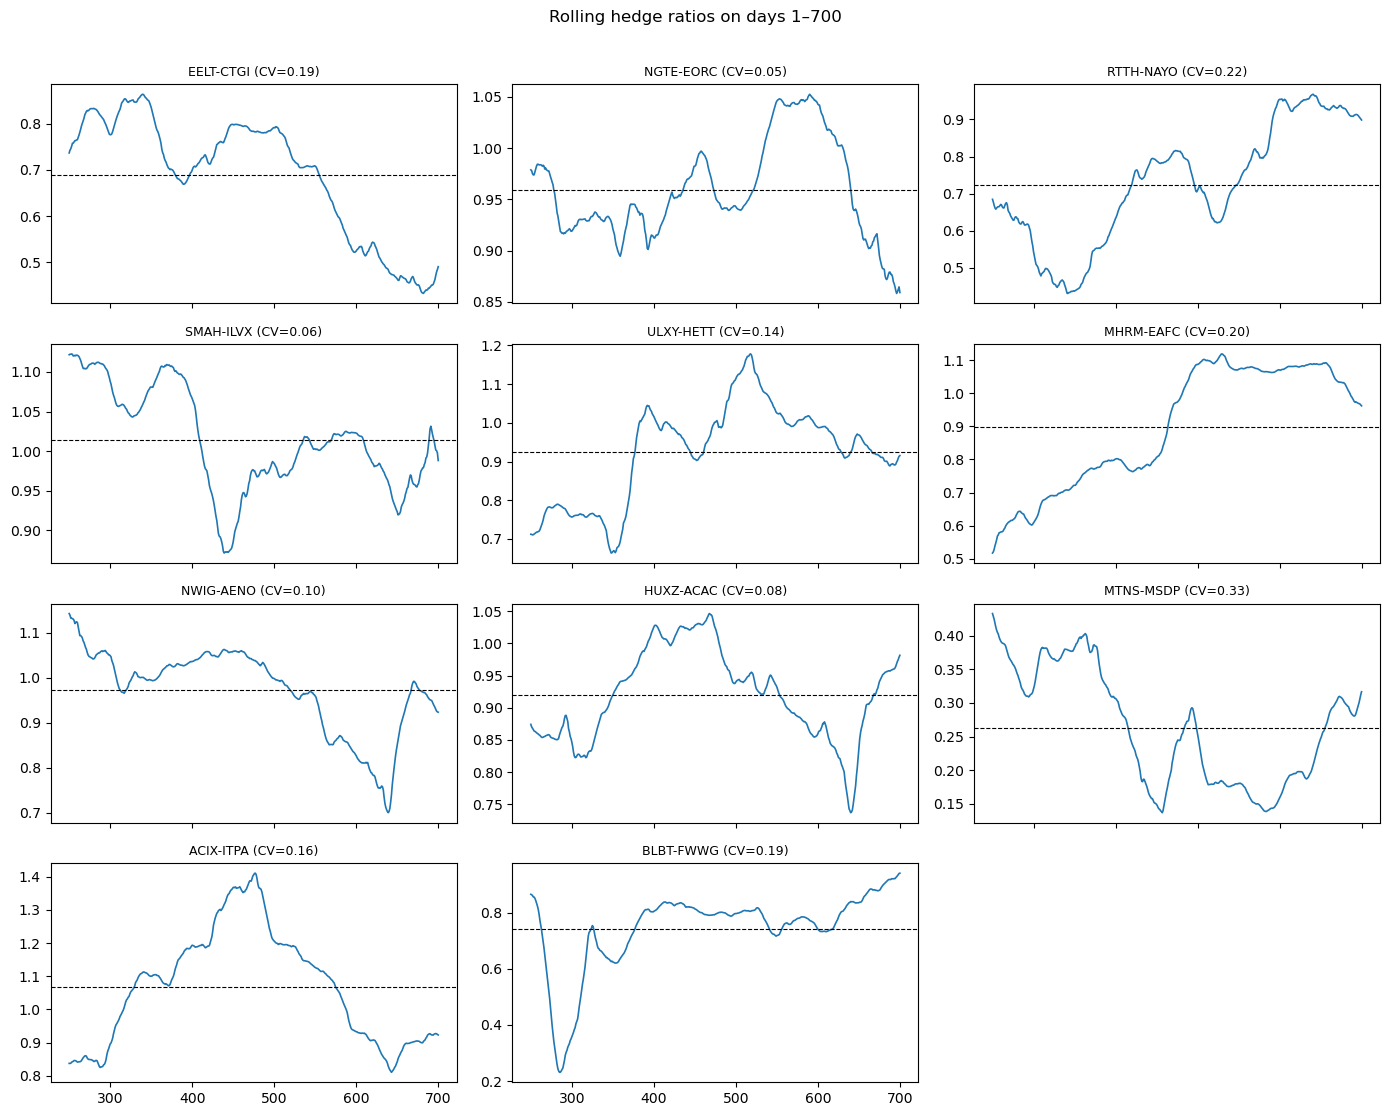

In [5]:
beta_rows = []
fig, axes = plt.subplots(4, 3, figsize=(14, 11), sharex=True)
axes = axes.ravel()

for axis, (idx_a, idx_b, ticker_a, ticker_b) in zip(axes, beta_strategy.PAIRS):
    values, days = [], []
    for end in range(ROLLING_WINDOW, VALIDATION_END + 1):
        beta = np.polyfit(np.log(prices[idx_b, end - ROLLING_WINDOW:end]), np.log(prices[idx_a, end - ROLLING_WINDOW:end]), 1)[0]
        values.append(beta)
        days.append(end)
    values = np.asarray(values)
    cv = values.std(ddof=1) / abs(values.mean())
    beta_rows.append({'pair': f'{ticker_a}-{ticker_b}', 'mean_beta': values.mean(), 'beta_cv': cv, 'beta_min': values.min(), 'beta_max': values.max()})
    axis.plot(days, values, linewidth=1.2)
    axis.axhline(values.mean(), color='black', linestyle='--', linewidth=0.8)
    axis.set_title(f'{ticker_a}-{ticker_b} (CV={cv:.2f})', fontsize=9)

for axis in axes[len(beta_strategy.PAIRS):]:
    axis.axis('off')
fig.suptitle('Rolling hedge ratios on days 1–700', y=1.01)
fig.tight_layout()

beta_stability = pd.DataFrame(beta_rows).sort_values('beta_cv')
display(beta_stability.style.format({'mean_beta': '{:.3f}', 'beta_cv': '{:.3f}', 'beta_min': '{:.3f}', 'beta_max': '{:.3f}'}).set_caption('Lower beta CV favours beta-hedged sizing'))

**Interpretation:** pairs with a low beta CV have a stable hedge ratio, so beta-hedged sizing is more defensible. Large beta ranges or CVs suggest equal-dollar sizing may be more robust.

## 2. Validation backtest comparison

The pair list and signal thresholds are identical. Only position sizing differs.

,sizing,score,mean_pl,ann_sharpe,max_drawdown,hit_rate,total_dvolume
0,Beta hedged,349.28,354.76,7.98,-2586.24,70.0%,"6,376,063"
1,Equal dollar,399.45,405.89,7.88,-2500.91,71.0%,"7,655,117"


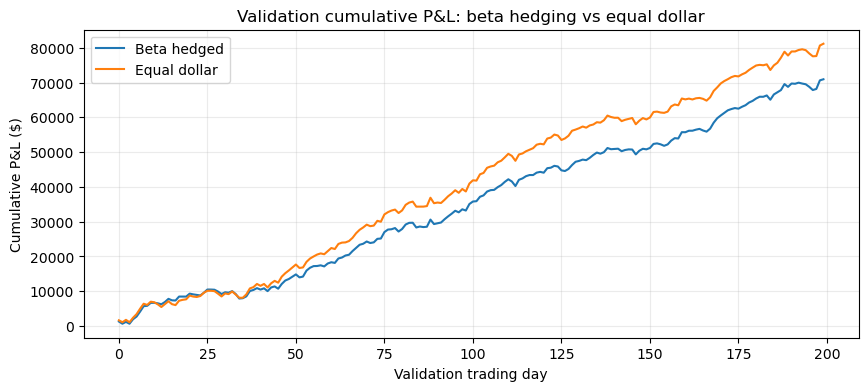

In [6]:
runs = []
for label, strategy in [('Beta hedged', beta_strategy), ('Equal dollar', equal_strategy)]:
    strategy.reset_state()
    result = run_backtest(prices, strategy.getMyPosition, eval_start=DISCOVERY_END, eval_end=VALIDATION_END)
    metrics = compute_metrics(result)
    runs.append({'sizing': label, **{key: metrics[key] for key in ['score', 'mean_pl', 'ann_sharpe', 'max_drawdown', 'hit_rate', 'total_dvolume']}, 'daily_pl': result.daily_pl})

comparison = pd.DataFrame([{key: value for key, value in run.items() if key != 'daily_pl'} for run in runs])
display(comparison.style.format({'score': '{:.2f}', 'mean_pl': '{:.2f}', 'ann_sharpe': '{:.2f}', 'max_drawdown': '{:.2f}', 'hit_rate': '{:.1%}', 'total_dvolume': '{:,.0f}'}).set_caption('Same pairs and signal; different sizing'))

plt.figure(figsize=(10, 4))
for run in runs:
    plt.plot(np.cumsum(run['daily_pl']), label=run['sizing'])
plt.title('Validation cumulative P&L: beta hedging vs equal dollar')
plt.xlabel('Validation trading day')
plt.ylabel('Cumulative P&L ($)')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## Decision guide

### Findings from days 501–700

- **Equal dollar is the better current choice:** score **399.45** versus **349.28**, with higher mean P/L (**$405.89** versus **$354.76**), a slightly smaller maximum drawdown, and a 71% hit rate.
- **Beta hedging is only slightly better risk-adjusted:** annualised Sharpe is **7.98** versus **7.88**, but it achieves this with lower P/L and lower turnover.
- Several hedge ratios drift materially (especially MTNS–MSDP; beta CV 0.325), so forcing beta-sized legs is not uniformly robust across this portfolio.

**Decision:** use equal-dollar sizing as the current baseline, while retaining beta hedging as a tested alternative. This is validation evidence only; do not choose based on days 701–1000.